# Optimal Loan Limit Increases: A Predict-then-Optimize Approach

**Author:** Christopher Nguu

I use this notebook to make the loan-limit problem explicit and reproducible. I build:

1. a synthetic East-African unsecured lending portfolio, with assumptions stated clearly rather than presented as proprietary lender data;
2. supervised models for PD, offer acceptance, and utilization, validated in an out-of-time style;
3. behavioral response functions that connect limit tiers to profit and risk;
4. a constrained MILP for allocating discrete limit increases; and
5. strategy comparisons under baseline and macro-stress scenarios.

The workflow is predict (ML), then optimize (OR), with the synthetic-data disclosure and the main limitations kept in the body of the notebook.

## 1. Setup and reproducibility


In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path(".").resolve()
if not (ROOT / "loan_limit_engine.py").exists():
    ROOT = Path("/workspace/loan-limit-optimization")
import sys
sys.path.insert(0, str(ROOT))

from loan_limit_engine import (
    ASSUMPTIONS, SCENARIOS, TIERS, STRATEGIES,
    build_synthetic_portfolio, aggregate_cohorts,
    expected_profit_cohort, solve_milp, run_all_simulations,
    plot_strategy_comparison, plot_macro_stress,
    plot_efficient_frontier, plot_tier_heatmap, plot_behavior_curves,
    DATA, FIG,
)
from ml_behavioral_models import simulate_labeled_offers, train_and_validate

plt.rcParams["figure.dpi"] = 120
print("Assumptions:")
for k, v in ASSUMPTIONS.items():
    print(f"  {k}: {v}")


Assumptions:
  market: East Africa unsecured digital / mobile-money-adjacent lending
  currency: KES (Kenya Shilling equivalent units)
  horizon_months: 12
  annual_interest_rate: 0.36
  fee_rate_on_draw: 0.02
  lgd: 0.65
  cost_of_capital: 0.12
  operating_cost_per_account: 150
  max_portfolio_el_ratio: 0.09
  max_cvar_proxy_ratio: 0.12
  max_share_high_risk: 0.45
  budget_increase_kes: 50000000
  n_cohorts: None


## 2. Modelling background (brief)

I treat loan-limit decisions as a combination of credit scoring, customer response modelling, and portfolio optimization. The relevant ideas include PD/LGD/EAD expected loss, limit elasticity, constrained optimization (including EL and CVaR), and predict-then-optimize pipelines. I implement a transparent version of that stack on synthetic data.

## 3. Synthetic portfolio

I generate $N=4000$ accounts with PD bands A–E, utilization buckets, tenure, and product (`personal` or `salary_advance`). The parameters are illustrative of digital unsecured lending in East Africa; they are not market quotes and do not represent proprietary lender data. All borrower-level inputs in this notebook are synthetic.

In [2]:
borrowers = build_synthetic_portfolio(4000)
borrowers.to_csv(DATA / "synthetic_borrowers.csv", index=False)
cohorts = aggregate_cohorts(borrowers)
cohorts.to_csv(DATA / "cohorts.csv", index=False)

print(f"Borrowers: {len(borrowers):,} | Cohorts: {len(cohorts)}")
display(borrowers[["pd_band","util_bucket","tenure_bucket","product","base_pd","current_limit","utilization"]].describe(include="all").T)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
borrowers["pd_band"].value_counts().reindex(list("ABCDE")).plot(kind="bar", ax=axes[0], color="#3498db", title="PD band")
borrowers["util_bucket"].value_counts().reindex(["low","med","high"]).plot(kind="bar", ax=axes[1], color="#e67e22", title="Utilization")
borrowers["product"].value_counts().plot(kind="bar", ax=axes[2], color="#27ae60", title="Product")
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG / "portfolio_composition.png", bbox_inches="tight")
plt.show()


Borrowers: 4,000 | Cohorts: 77


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
pd_band,4000,5,E,1174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
util_bucket,4000,3,med,3533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_bucket,4000,3,established,2211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product,4000,2,personal,2502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
base_pd,4000.0,NaN,NaN,NaN,0.141902,0.093464,0.015,0.067178,0.118251,0.196584,0.35
current_limit,4000.0,NaN,NaN,NaN,13496.625,12944.354568,1500.0,5500.0,9000.0,16000.0,80000.0
utilization,4000.0,NaN,NaN,NaN,0.557562,0.104921,0.229975,0.486392,0.559921,0.632536,0.846875


## 4. ML layer: PD, acceptance, utilization (OOT validation)

I simulate historical offers and use a vintage-style 70/30 split as an out-of-time analogue. I compare interpretable logistic PD with GBM, use logistic regression for acceptance, and model utilization with GBM. I report AUC, Brier score, average precision, MAE, and $R^2$, together with permutation importance and calibration plots.

OOT validation metrics
{
  "pd_logistic": {
    "name": "logistic_pd",
    "auc": 0.732102491202722,
    "brier": 0.1819536419989854,
    "ap": 0.303192035231777
  },
  "pd_gbm": {
    "name": "gbm_pd",
    "auc": 0.702480133299154,
    "brier": 0.11895389975901703,
    "ap": 0.2280598787998199
  },
  "acceptance_logit": {
    "auc": 0.7621047273652732,
    "brier": 0.12015353640022385
  },
  "utilization_gbm": {
    "mae": 0.02484627257755524,
    "r2": 0.9171407036439309,
    "n_test_accepted": 1014
  }
}
Chosen PD model: logistic_pd | split: out_of_time_vintage_70_30


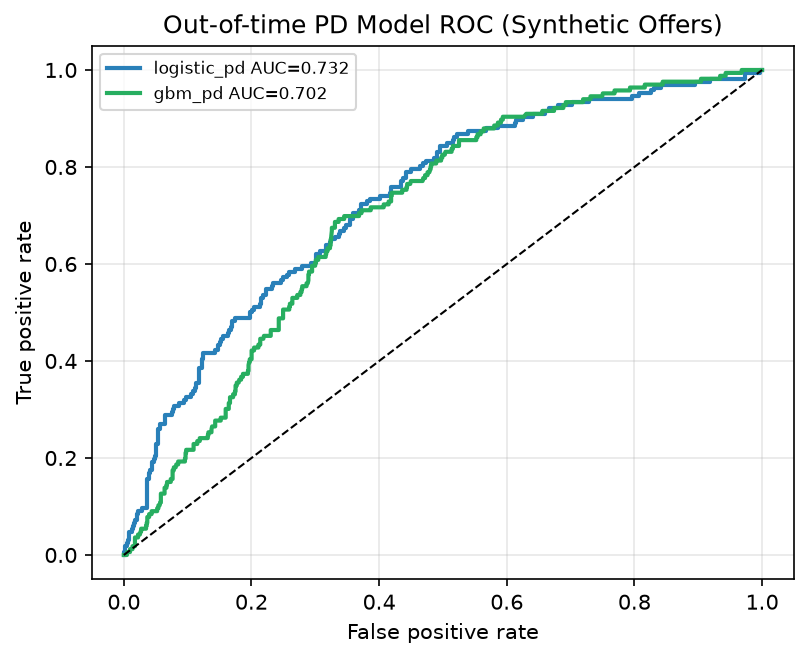

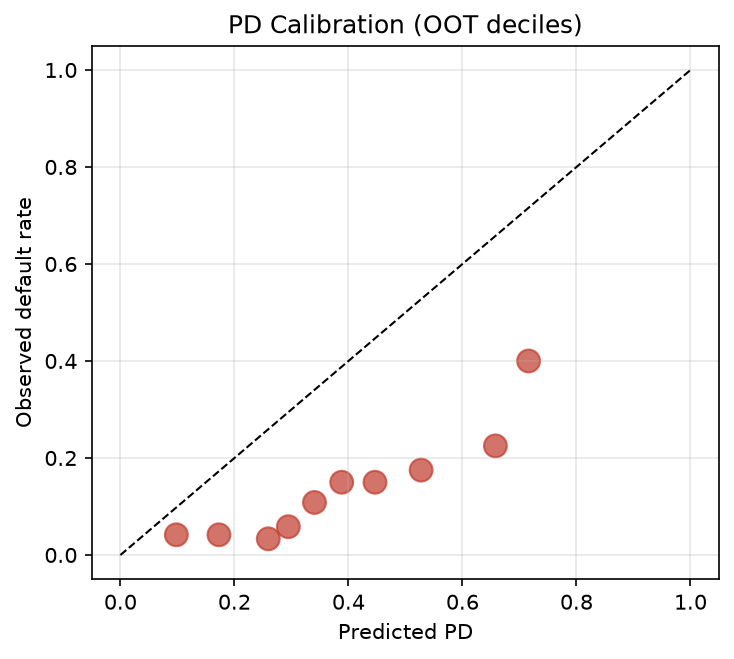

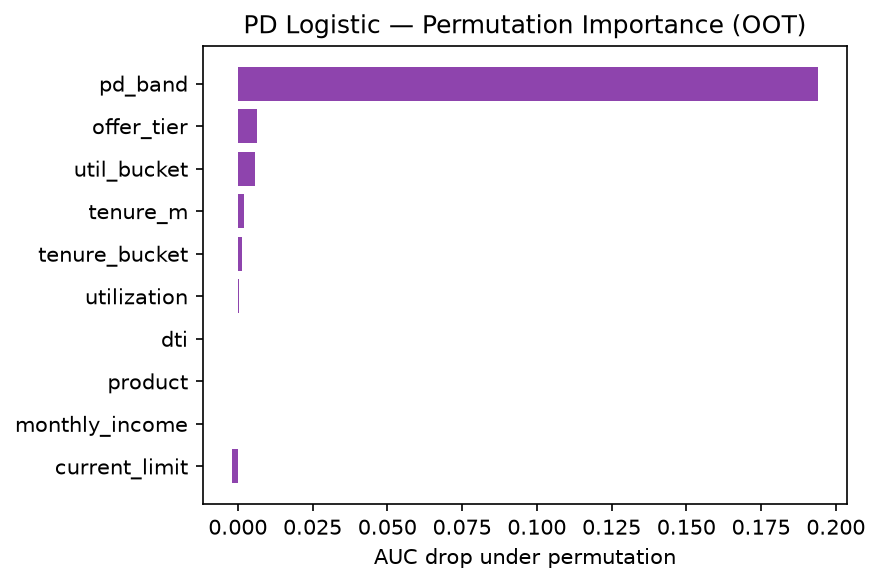

In [3]:
offers = simulate_labeled_offers(borrowers, n_offers_per=1)
offers.to_csv(DATA / "synthetic_offers.csv", index=False)
ml_results, logit_pd, acc_model, util_model = train_and_validate(offers)

print("OOT validation metrics")
print(json.dumps(ml_results["models"], indent=2))
print("Chosen PD model:", ml_results["chosen_pd_model"], "| split:", ml_results["split"])

from IPython.display import Image, display
for name in ["pd_roc_oot.png", "pd_calibration.png", "pd_permutation_importance.png"]:
    p = FIG / name
    if p.exists():
        display(Image(filename=str(p)))


## 5. Behavioral model and profit identity

For increase fraction $\delta \in \mathcal{T}=\{0,0.1,0.25,0.5,1.0\}$, I combine acceptance, utilization response, PD uplift, and churn into expected profit:

$$\pi = r\cdot\mathrm{EAD} + \mathrm{fees} - \mathrm{EAD}\cdot\mathrm{PD}\cdot\mathrm{LGD} - \mathrm{capital} - \mathrm{opex} - \mathrm{churn\ cost}$$

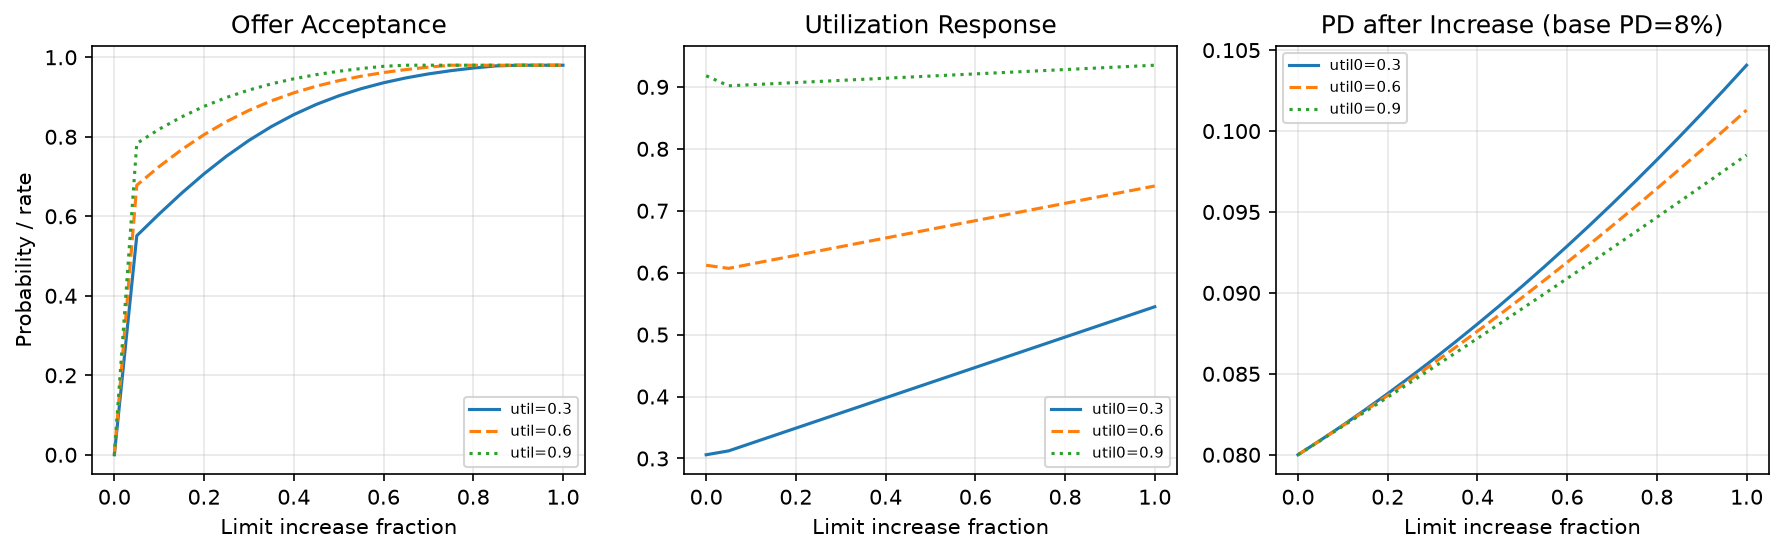

Largest cohort: E|med|established|personal n= 426
  tier=0%: profit/acct=313.4, PD=0.263, churn=0.270, p_acc=0.000
  tier=10%: profit/acct=402.3, PD=0.267, churn=0.153, p_acc=0.641
  tier=25%: profit/acct=493.4, PD=0.275, churn=0.121, p_acc=0.778
  tier=50%: profit/acct=656.6, PD=0.292, churn=0.081, p_acc=0.915
  tier=100%: profit/acct=878.6, PD=0.332, churn=0.038, p_acc=0.980


In [4]:
_ = plot_behavior_curves()
from IPython.display import Image, display
display(Image(filename=str(FIG / "behavior_curves.png")))

row = cohorts.sort_values("n", ascending=False).iloc[0]
print("Largest cohort:", row.cohort, "n=", int(row.n))
for t in TIERS:
    e = expected_profit_cohort(row.n, row.current_limit, row.utilization, row.base_pd, t, SCENARIOS[0])
    print(f"  tier={t:.0%}: profit/acct={e['exp_profit_per_acct']:.1f}, PD={e['exp_pd']:.3f}, churn={e['exp_churn']:.3f}, p_acc={e['p_accept']:.3f}")


## 6. MILP formulation

I assign each cohort $c$ to one tier $t$ using a binary decision $x_{c,t}\in\{0,1\}$.

$$
\max_x \sum_{c,t}\Pi_{c,t}x_{c,t}
\quad
\text{s.t.}
\sum_t x_{c,t}=1,
\;
\sum_{c,t}\Delta L_{c,t}x_{c,t}\le B,
\;
\mathrm{EL}\le\rho\cdot\mathrm{EAD},
\;
\text{high-risk and stress proxies.}
$$

I precompute cohort economics $\Pi_{c,t},\mathrm{EL}_{c,t},\Delta L_{c,t}$ by lookup, which keeps the MILP tractable and auditable.

MILP status: Optimal
{'status': 'Optimal', 'scenario': 'baseline', 'n_accounts': 4000.0, 'total_profit': 10249002.7117, 'total_el': 3916539.9622, 'total_ead': 54502600.8847, 'el_ratio': 0.0719, 'default_rate_proxy': 0.1104, 'incremental_limit': 29127527.1041, 'budget_used_pct': 58.2551, 'avg_churn': 0.1478, 'high_risk_ead_share': 0.2342, 'profit_per_account': 2562.2507}


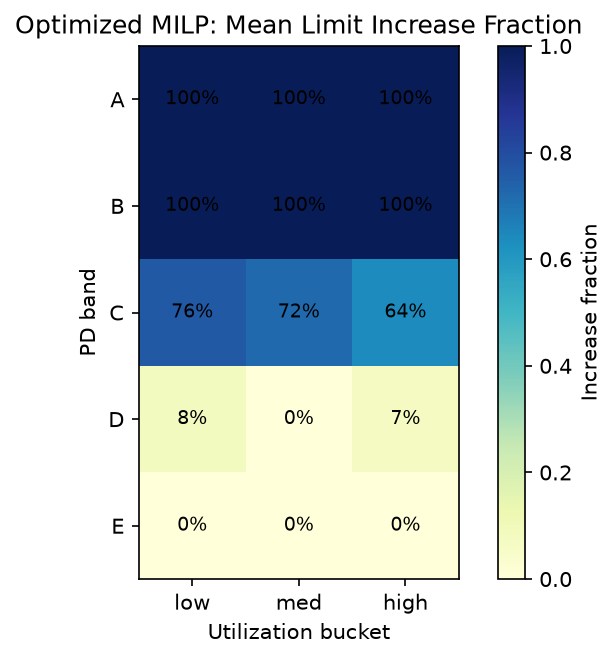

In [5]:
alloc_opt, metrics_opt = solve_milp(cohorts, SCENARIOS[0])
print("MILP status:", metrics_opt["status"])
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in metrics_opt.items()})
alloc_opt.to_csv(DATA / "optimized_allocation_baseline.csv", index=False)
_ = plot_tier_heatmap(alloc_opt)
from IPython.display import Image, display
display(Image(filename=str(FIG / "tier_heatmap_optimized.png")))


## 7. Strategy simulation and macro stress

I compare no increase, a uniform +25% policy, a risk-based ladder, a greedy high-utilization rule, a contextual-bandit heuristic, and the constrained MILP under baseline, mild-recession, and severe scenarios.

=== Baseline comparison ===
        strategy  total_profit_m  profit_lift_pct  default_rate_pct  el_ratio_pct  avg_churn
     no_increase        4.108286         0.000000         12.886842      8.376447   0.254016
      uniform_25        5.877183        43.056814         13.370057      8.709136   0.106953
      risk_based        5.731255        39.504785         11.967886      7.784161   0.159929
greedy_high_util        5.067096        23.338447         12.262464      7.973904   0.208680
bandit_heuristic       11.817193       187.642921         16.066542     10.468778   0.052570
  optimized_milp       10.249003       149.471508         11.039094      7.185969   0.147826


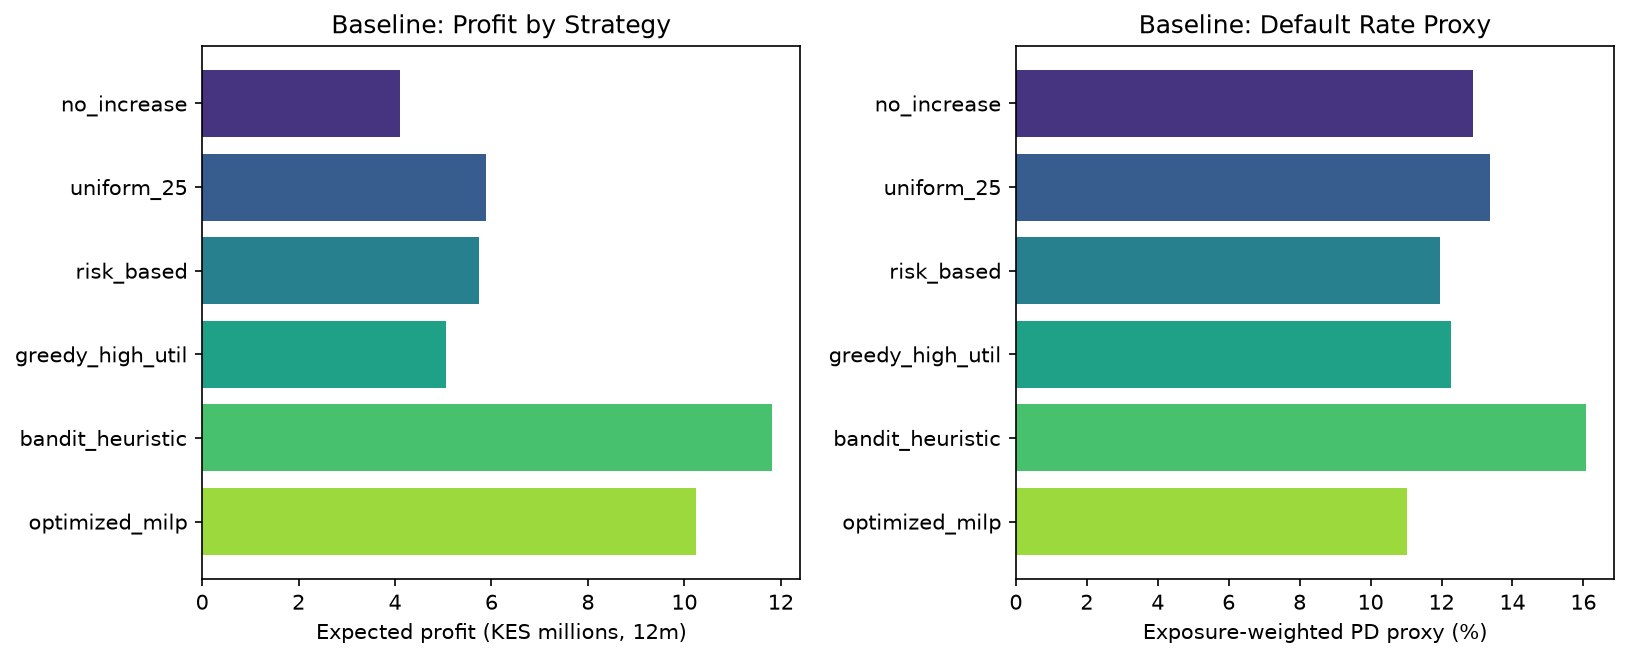

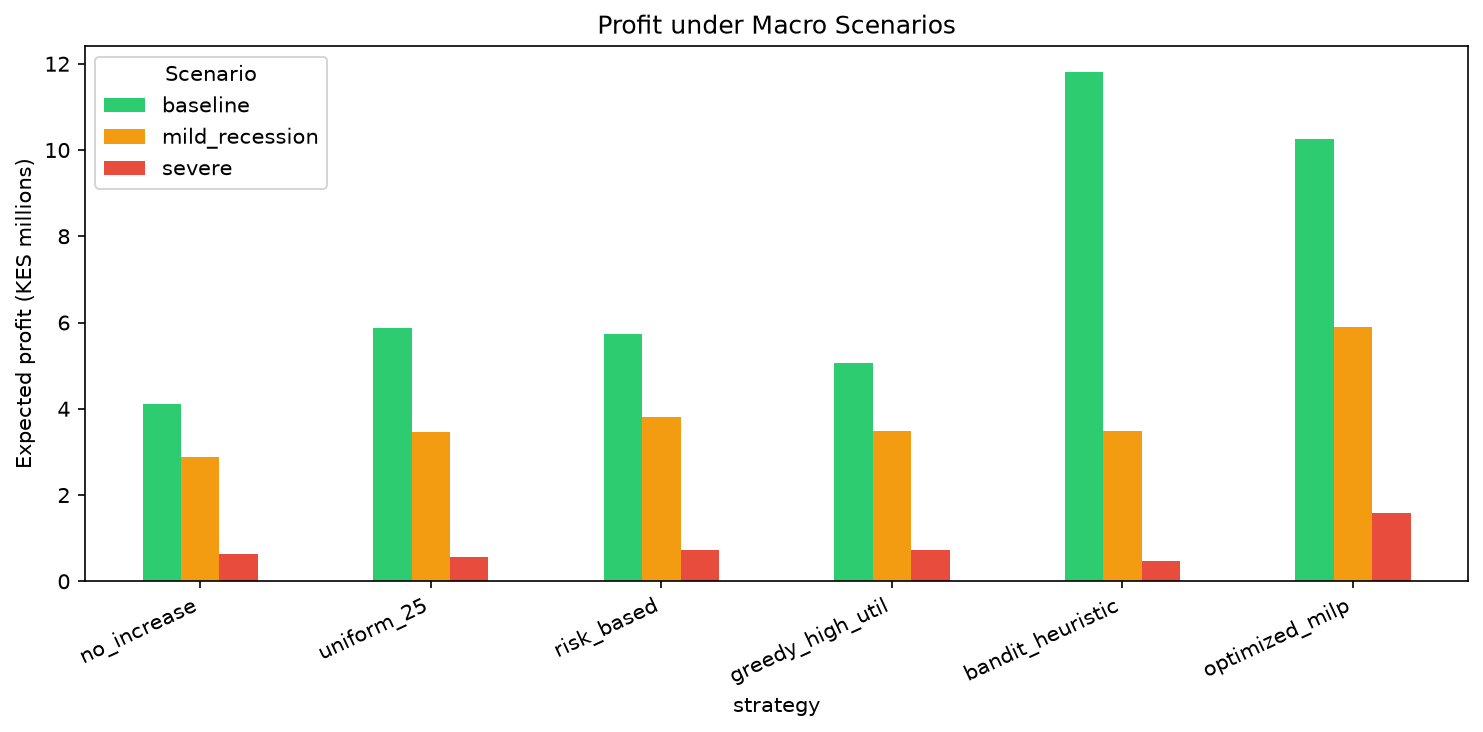

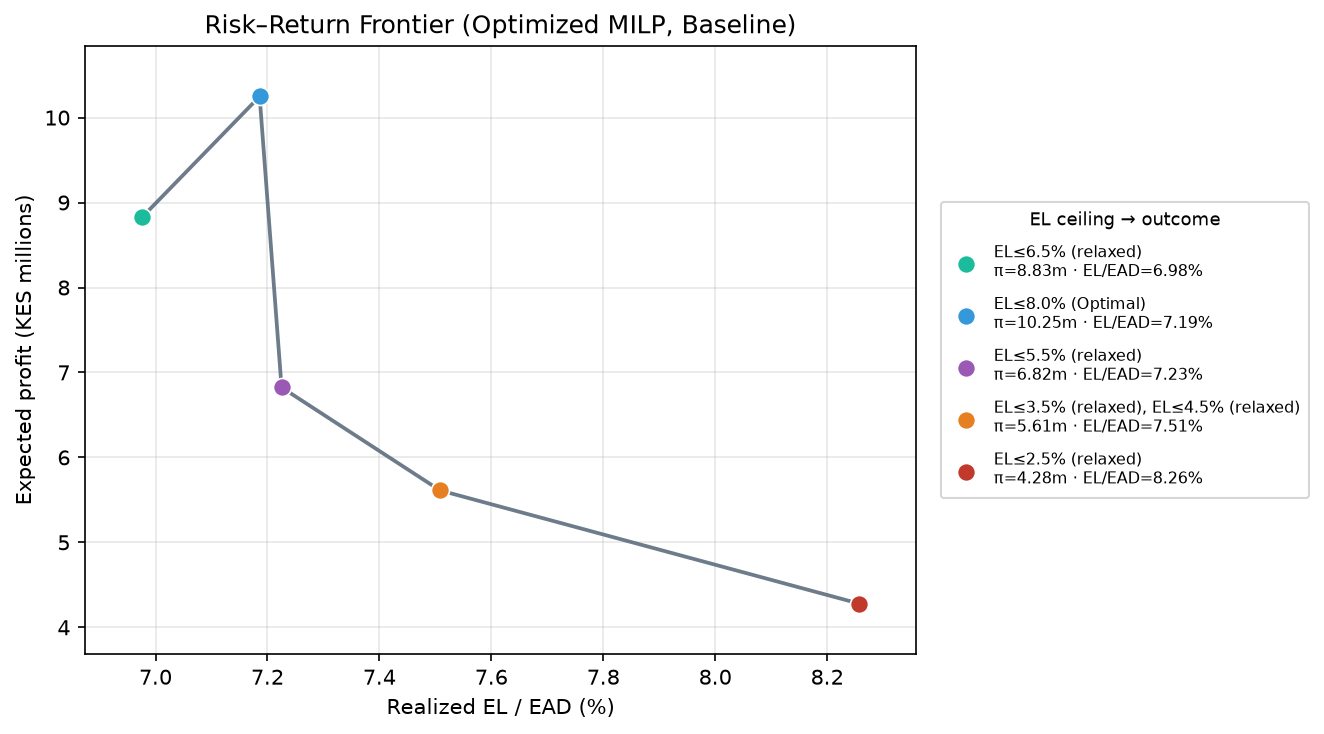

In [6]:
summary, detail = run_all_simulations(cohorts)
summary.to_csv(DATA / "strategy_summary.csv", index=False)

baseline = summary[summary.scenario == "baseline"][
    ["strategy", "total_profit", "profit_lift_pct", "default_rate_proxy", "el_ratio", "incremental_limit", "avg_churn", "status"]
].copy()
baseline["total_profit_m"] = baseline["total_profit"] / 1e6
baseline["default_rate_pct"] = 100 * baseline["default_rate_proxy"]
baseline["el_ratio_pct"] = 100 * baseline["el_ratio"]
print("=== Baseline comparison ===")
print(baseline[["strategy", "total_profit_m", "profit_lift_pct", "default_rate_pct", "el_ratio_pct", "avg_churn"]].to_string(index=False))

_ = plot_strategy_comparison(summary)
_ = plot_macro_stress(summary)
_ = plot_efficient_frontier(cohorts)

from IPython.display import Image, display
for name in ["strategy_comparison_baseline.png", "macro_stress_profit.png", "efficient_frontier.png"]:
    display(Image(filename=str(FIG / name)))


## 8. Discussion

- I find that the constrained MILP raises profit against no increase while improving the EL ratio and PD proxy relative to unconstrained heuristics.
- The bandit can produce higher raw profit by ignoring portfolio EL. I treat it as an upper-bound comparison, not as a policy without guardrails.
- Macro stress shifts the frontier, so scenario playbooks matter in emerging-market cycles.
- I prefer logistic PD when its out-of-time AUC is competitive, while using GBM where the utilization response benefits from it.

## 9. Limitations

The main limitations are synthetic data, parametric behavior, no explicit default clustering, a certainty-equivalent MILP, and no fairness audit. Live calibration would require bureau or telco features and offer-history experiments.

## 10. Operational recommendations

I would use a champion–challenger test, re-solve monthly, freeze accounts using early-warning signals, document model risk, and couple limit changes with risk-based pricing.

In [7]:
key = {
    "baseline_table": baseline.to_dict(orient="records"),
    "milp": metrics_opt,
    "ml": {k: v for k, v in ml_results.items() if k != "pd_feature_importance"},
    "assumptions": ASSUMPTIONS,
}
with open(DATA / "key_metrics.json", "w") as f:
    json.dump(key, f, indent=2, default=str)
print("Wrote", DATA / "key_metrics.json")
print("Notebook run complete.")


Wrote /workspace/loan-limit-optimization/data/key_metrics.json
Notebook run complete.
